In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
points = np.random.randint(0,10,(10,2))

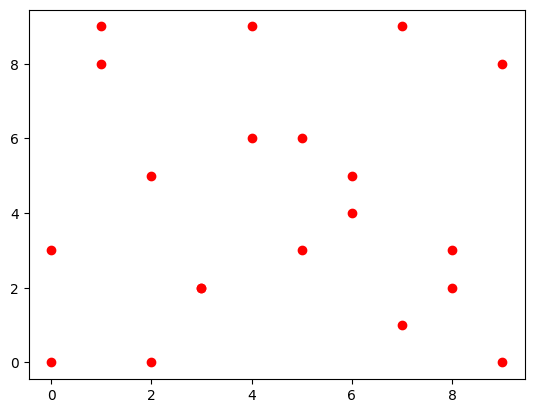

In [3]:
plt.plot(points, 'ro')

In [5]:
from IPython import get_ipython

In [6]:
ip = get_ipython()

In [7]:
import subprocess, json


In [8]:
from pathlib import Path

In [9]:
import httpx

In [10]:
from fastcore.foundation import AttrDict
from fastcore.xtras import dict2obj, obj2dict

In [11]:
def get_contents():
    conn_file = ip.config.IPKernelApp.connection_file
    kernel_id = Path(conn_file).stem.replace('kernel-', '')

    output = subprocess.check_output(['jupyter', 'server', 'list', '--json'])
    servers = [json.loads(x) for x in output.decode().splitlines() ]
    # if multiple servers, check current kernel id from get_ipython
    
    token = servers[0]['token']
    url = servers[0]['url']

    base = url.rstrip('/')

    client = httpx.Client(base_url=base,
                          headers={'Authorization': f'token {token}'})
    sessions = client.get('/api/sessions').json()
    my_session = None
    for s in sessions:
        if s['kernel']['id'] == kernel_id:
            my_session = s
    
    contents = client.get(f"/api/contents/{my_session['path']}",
                       params={'content':1}).json()
    
    contents = dict2obj(contents)
    return contents

In [12]:
def get_cells():
    # TODO: save this at init
    contents = get_contents()
    
    cells = contents.content.cells
    return cells

Here's what I want to do. 
Create a magic command. 
When that runs, read the cells above the magic command cell using the api.
Run the LLM and respond. 

In [13]:
from IPython.core.magic import Magics, magics_class, line_magic, cell_magic

In [14]:
from openai import OpenAI
from IPython.display import display, Markdown
from dotenv import load_dotenv
import os

In [15]:
load_dotenv()

True

In [22]:
@magics_class
class RunAI(Magics):
    def __init__(self, shell):
        super().__init__(shell)
        self.content = ''
        self.user_message = ''
        # Register event hook
        get_ipython().events.register('pre_run_cell', self.get_cell_id)
        self.client = OpenAI(
            api_key=os.environ["OPENCODE_KEY"],
            base_url="https://opencode.ai/zen/go/v1"
        )

    def make_context(self, cell_id):
        cells = get_cells()
        for i, c in enumerate(cells):
            if c.id == cell_id:  
                break
            self.content += "\n---------\n"
            self.content += c.source
        
    def get_cell_id(self, info):
        if info.raw_cell.splitlines()[0].split()[0] == "%ai":
            assert self.content == ''
            assert self.user_message == ''
            self.make_context(info.cell_id)
            self.user_message = ' '.join(info.raw_cell.split()[1:])
            
    @cell_magic
    def ai(self, line, cell):
        # ip.set_next_input("print('hello ai')")
        r = ''
        try:
            response = self.client.chat.completions.create(
                model="deepseek-v4-flash",  # or glm-5.2, glm-5.1, kimi-k2.6, deepseek-v4-pro, deepseek-v4-flash, mimo-v2.5, mimo-v2.5-pro
                messages=[
                    {"role": "system", "content": f"You are a very concise and helpful coding assistant. \n\nHere is the user's jupyter notebook code: {self.content}"},
                    {"role": "user", "content": self.user_message}
                ],
                # reasoning_effort="none"
            )
            r = Markdown(response.choices[0].message.content)
        except Exception as e:
            r = f"an error occurred during llm request: {e}"
        self.content = ''
        self.user_message = ''
        return r

In [25]:
%ai write the get_context function outside the class please

Here's the standalone `get_context` function, extracted from the class and usable directly:

```python
def get_context(cell_id):
    """Return the concatenated source of all cells above the given cell_id."""
    cells = get_cells()          # uses the globally available helper
    content = ''
    for c in cells:
        if c.id == cell_id:
            break
        content += "\n---------\n" + c.source
    return content
```

This function can be called from anywhere (e.g., in a magic) without relying on class state. It accumulates the source of cells exactly as before, stopping when it hits the cell with `cell_id` (the current cell).

In [17]:
def ai_transformer(lines):
    if lines and lines[0].strip().startswith('%ai'):
        lines[0] = lines[0].strip()[3:].strip()  # everything after %ai
        lines = ["%%ai"] + lines
    return lines

In [18]:
ip.input_transformer_manager.cleanup_transforms.append(ai_transformer)

In [19]:
ip.register_magics(RunAI)

In [20]:
%ai Will this work?

Your approach has creative elements but contains several bugs that will prevent it from working. Here’s a detailed breakdown of the issues and how to fix them.

## Critical Bugs

### 1. ❌ Mixing dict-style and attribute-style access
In `get_cells()` you use `dict2obj` (from `fastcore.xtras`), which converts nested dicts into objects with attribute access.  
Then in `make_context()` you try `c['id']` and `c.source` – but `c` is now an object, so:
- `c['id']` → `TypeError: 'AttrDict' object is not subscriptable`  
- `c.source` is fine (attribute access)  

**Fix:** Use `c.id` instead of `c['id']`.

### 2. ❌ Input transformer registration
You wrote `ip.input_transformer_manager.cleanup_transforms.append(...)`.  
The correct name is `ip.input_transformers_cleanup` (a list on the shell, not via `input_transformer_manager`).  

**Fix:**  
```python
ip.input_transformers_cleanup.append(ai_transformer)
```

### 3. ❌ `get_cell_id` uses `info.cell_id` incorrectly
- `pre_run_cell` event passes an `ExecutionInfo` object (`.cell_id` attribute exists in recent IPython/Jupyter, but not always).  
- More importantly, `info.raw_cell` may be the **post‑transformation** source, not the original. If your transformer changes `%ai ...` to `%%ai\n...`, then `raw_cell` might already be the transformed version, so checking for `%ai` at the start could fail.

**Better approach:** Rely on the transformer to set a flag or directly use `line` argument in the cell magic.

### 4. ❌ Double setting of `user_message`
Your `get_cell_id` sets `self.user_message` from `info.raw_cell`.  
But the cell magic `ai` receives `line` (which already contains the user’s query).  
You then ignore `line` and use `self.user_message` – this works if you only ever use `%ai`, but it’s fragile.

**Simplify:** Don’t use the `pre_run_cell` hook at all. Let your input transformer do everything, and inside the cell magic use the `line` argument directly.

### 5. ❌ `make_context` builds context only when `%ai` is detected
The hook sets context only for cells beginning with `%ai`.  
If someone uses `%%ai` manually, `self.content` remains empty.  
Again, relying on the transformer is cleaner.

## Suggested Simplified Design

1. **Use only the input transformer** to convert `%ai ...` into `%%ai\n...`.  
2. **Cell magic** `%%ai`: takes `line` as the user prompt, gets context from previous cells via API, calls LLM, returns result.  
3. **No `pre_run_cell` hook** required.

Here’s a refactored version of your `RunAI` class:

```python
@magics_class
class RunAI(Magics):
    def __init__(self, shell):
        super().__init__(shell)
        self.client = OpenAI(
            api_key=os.environ["OPENCODE_KEY"],
            base_url="https://opencode.ai/zen/go/v1"
        )

    def _get_context(self, current_cell_id):
        cells = get_cells()   # returns list of AttrDicts thanks to dict2obj
        context = []
        for c in cells:
            if c.id == current_cell_id:
                break
            context.append(c.source)
        return "\n---------\n".join(context)

    @cell_magic
    def ai(self, line, cell):
        # line = user prompt (everything after %ai ... or first line after %%ai)
        # cell = the rest of the cell (ignored)
        if not line.strip():
            return "Please provide a prompt after %%ai or %ai"

        # Get current cell ID from the shell’s execution info
        # You can store cell_id in a thread-local or use the event info if available
        # A workaround: use the last execution info (not robust)
        from IPython import get_ipython
        shell = get_ipython()
        if hasattr(shell, 'last_execution_info'):
            current_id = shell.last_execution_info.cell_id
        else:
            # fallback: search through cells by source (slow)
            cells = get_cells()
            current_source = shell.user_ns.get('In')[-1]  # last input
            current_id = None
            for c in cells:
                if c.source == current_source:
                    current_id = c.id
                    break
            if not current_id:
                return "Could not identify current cell."

        context = self._get_context(current_id)
        try:
            response = self.client.chat.completions.create(
                model="deepseek-v4-flash",
                messages=[
                    {"role": "system", "content": f"Notebook context:\n{context}"},
                    {"role": "user", "content": line}
                ]
            )
            return Markdown(response.choices[0].message.content)
        except Exception as e:
            return f"Error: {e}"
```

Then register after fixing the transformer list:

```python
ip.input_transformers_cleanup.append(ai_transformer)
ip.register_magics(RunAI)
```

## Other Minor Issues

- **`get_cells` uses subprocess** – slow but okay for a hack.  
- **Multiple servers** – you take first server’s token/URL.  
- **`get_cell_id`** event hook is not needed; remove it.  

After these fixes your magic should work for both `%ai` and `%%ai`. The biggest hurdle is the dict/object mixture and the transformer registration.

Would you like me to provide a corrected full implementation?

In [21]:
%ai where is the c['id'] bug? 

The bug is in the `make_context` method:

```python
def make_context(self, cell_id):
    cells = get_cells()
    for i, c in enumerate(cells):
        if c['id'] == cell_id:   # <-- This line
            break
        ...
```

`get_cells()` returns cells from `get_contents()`, which uses `dict2obj()` from `fastcore.xtras`. This converts nested dictionaries into objects with attribute access only (not subscriptable). So `c` is an object, not a dict, and **`c['id']` fails** (raises `TypeError` or `AttributeError`).  

It should be `c.id` to match the attribute style used elsewhere (e.g., `c.source`).

In [74]:
ip.events.callbacks['pre_run_cell'].clear()


In [27]:
get_cells()[-1].id

'5e47314c-1b24-433b-a9e6-087a6744efe8'

In [26]:
def get_context(cell_id):
    """Return the concatenated source of all cells above the given cell_id."""
    cells = get_cells()          # uses the globally available helper
    content = ''
    for c in cells:
        if c.id == cell_id:
            break
        content += "\n---------\n" + c.source
    return content

In [32]:
cid = get_cells()[-1].id

In [35]:
ip.set_next_input("print('hi')")

In [36]:
print('hi')

hi


In [ ]:
%ai help me please

In [33]:
print(get_context(cid))


---------
import numpy as np
import matplotlib.pyplot as plt
---------
points = np.random.randint(0,10,(10,2))
---------
plt.plot(points, 'ro')
---------
from IPython import get_ipython
---------
ip = get_ipython()
---------
import subprocess, json

---------
from pathlib import Path
---------
import httpx
---------
from fastcore.foundation import AttrDict
from fastcore.xtras import dict2obj, obj2dict
---------
def get_contents():
    conn_file = ip.config.IPKernelApp.connection_file
    kernel_id = Path(conn_file).stem.replace('kernel-', '')

    output = subprocess.check_output(['jupyter', 'server', 'list', '--json'])
    servers = [json.loads(x) for x in output.decode().splitlines() ]
    # if multiple servers, check current kernel id from get_ipython
    
    token = servers[0]['token']
    url = servers[0]['url']

    base = url.rstrip('/')

    client = httpx.Client(base_url=base,
                          headers={'Authorization': f'token {token}'})
    sessions = client.get('/